## Assignment 8: Pandas Groupby with Hurricane Data

In [169]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [170]:
df.shape

(716165, 12)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716165 entries, 0 to 716164
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       716165 non-null  object        
 1   SEASON    716165 non-null  int64         
 2   NUMBER    716165 non-null  int64         
 3   BASIN     716165 non-null  object        
 4   SUBBASIN  716165 non-null  object        
 5   NAME      390393 non-null  object        
 6   ISO_TIME  716165 non-null  datetime64[ns]
 7   NATURE    716165 non-null  object        
 8   LAT       716165 non-null  float64       
 9   LON       716165 non-null  float64       
 10  WMO_WIND  157570 non-null  float64       
 11  WMO_PRES  160275 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 65.6+ MB


### dataset has 716,165 rows

In [172]:
list(df['BASIN'].unique())

['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA']

In [173]:
(df['BASIN'] == 'NA').sum()

126392

In [174]:
df['BASIN']

0         NI
1         NI
2         NI
3         NI
4         NI
          ..
716160    NI
716161    NI
716162    NI
716163    NI
716164    NI
Name: BASIN, Length: 716165, dtype: object

### 1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [175]:
df['BASIN'].unique()

array(['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA'], dtype=object)

In [176]:
df['SUBBASIN'].unique()

array(['BB', 'AS', 'MM', 'GM', 'NA', 'CS', 'WA', 'EA', 'CP'], dtype=object)

In [177]:
df['NATURE'].unique()

array(['NR', 'TS', 'ET', 'SS', 'MX', 'DS'], dtype=object)

In [178]:
list(df.groupby('BASIN').groups.keys())

['EP', 'NA', 'NI', 'SA', 'SI', 'SP', 'WP']

In [179]:
list(df.groupby('SUBBASIN').groups.keys())

['AS', 'BB', 'CP', 'CS', 'EA', 'GM', 'MM', 'NA', 'WA']

In [180]:
list(df.groupby('NATURE').groups.keys())

['DS', 'ET', 'MX', 'NR', 'SS', 'TS']

### 2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [181]:
df.rename (columns={'WMO_WIND': 'WIND'})
Wind

{'WMO_WIND': 'WIND'}

In [182]:
df.rename(columns={'WMO_WIND': 'WIND'}, inplace=True)
df.rename

<bound method DataFrame.rename of                   SID  SEASON  NUMBER BASIN SUBBASIN   NAME  \
0       1842298N11080    1842       1    NI       BB    NaN   
1       1842298N11080    1842       1    NI       BB    NaN   
2       1842298N11080    1842       1    NI       BB    NaN   
3       1842298N11080    1842       1    NI       BB    NaN   
4       1842298N11080    1842       1    NI       BB    NaN   
...               ...     ...     ...   ...      ...    ...   
716160  2024147N19089    2024      27    NI       BB  REMAL   
716161  2024147N19089    2024      27    NI       BB  REMAL   
716162  2024147N19089    2024      27    NI       BB  REMAL   
716163  2024147N19089    2024      27    NI       BB  REMAL   
716164  2024147N19089    2024      27    NI       BB  REMAL   

                  ISO_TIME NATURE      LAT      LON  WIND  WMO_PRES  
0      1842-10-25 03:00:00     NR  10.9000  80.3000   NaN       NaN  
1      1842-10-25 06:00:00     NR  10.8709  79.8265   NaN       NaN  

In [183]:
df.rename(columns={'WMO_PRES': 'PRES'}, inplace=True)
df.rename

<bound method DataFrame.rename of                   SID  SEASON  NUMBER BASIN SUBBASIN   NAME  \
0       1842298N11080    1842       1    NI       BB    NaN   
1       1842298N11080    1842       1    NI       BB    NaN   
2       1842298N11080    1842       1    NI       BB    NaN   
3       1842298N11080    1842       1    NI       BB    NaN   
4       1842298N11080    1842       1    NI       BB    NaN   
...               ...     ...     ...   ...      ...    ...   
716160  2024147N19089    2024      27    NI       BB  REMAL   
716161  2024147N19089    2024      27    NI       BB  REMAL   
716162  2024147N19089    2024      27    NI       BB  REMAL   
716163  2024147N19089    2024      27    NI       BB  REMAL   
716164  2024147N19089    2024      27    NI       BB  REMAL   

                  ISO_TIME NATURE      LAT      LON  WIND  PRES  
0      1842-10-25 03:00:00     NR  10.9000  80.3000   NaN   NaN  
1      1842-10-25 06:00:00     NR  10.8709  79.8265   NaN   NaN  
2      1842

### 3) Get the 10 largest rows in the dataset by WIND

In [184]:
df.nlargest(n=10, columns='WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


### 4) Group the data on SID and get the 10 largest hurricanes by WIND

In [185]:
df.groupby('SID').WIND.count().nlargest(10)

SID
2015068S12151    142
1973325S09091    137
1899215N12329    133
1994222N11267    121
1971249N26289    118
2015364S09190    109
1973061S10155    108
1976015S18122    106
2008033S11083    106
1978075S14084    105
Name: WIND, dtype: int64

### 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

<Axes: xlabel='SID'>

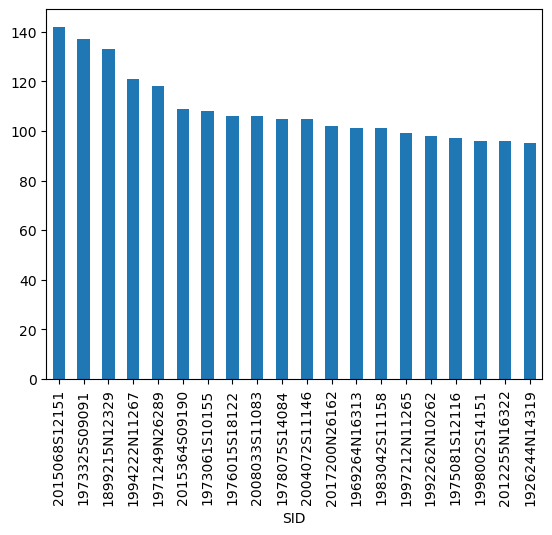

In [186]:
df.groupby('SID').WIND.count().nlargest(20).plot(kind='bar')

unsure what _"Use the name on the x-axis"_ means in homework? SID?

### 7) Plot the count of unique hurricanes by Basin

<Axes: xlabel='BASIN'>

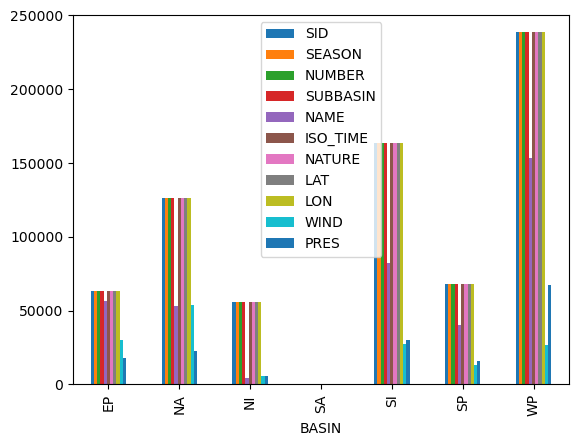

In [187]:
df.groupby('BASIN').count().plot(kind='bar')

### 8) Make a hexbin of the location of datapoints in Latitude and Longitude

<Axes: xlabel='LON', ylabel='LAT'>

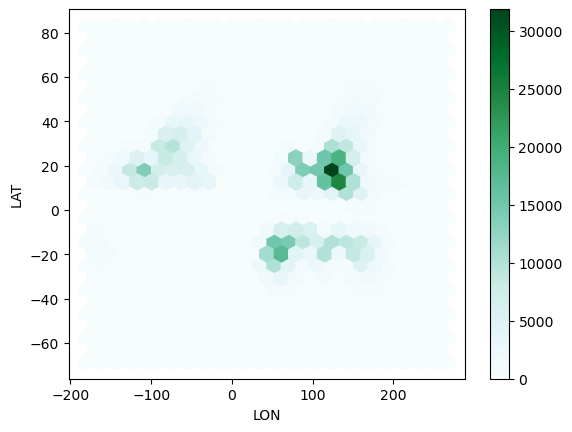

In [188]:
df.plot.hexbin(x='LON', y='LAT', gridsize=25)

### 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

In [189]:
df.loc[df['NAME'] == 'KATRINA']

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
332516,1967242N18253,1967,86,EP,MM,KATRINA,1967-08-30 00:00:00,TS,17.8000,-107.2000,45.0,NaN
332517,1967242N18253,1967,86,EP,MM,KATRINA,1967-08-30 03:00:00,TS,17.9859,-107.5960,NaN,NaN
332518,1967242N18253,1967,86,EP,MM,KATRINA,1967-08-30 06:00:00,TS,18.2120,-107.9900,45.0,NaN
332519,1967242N18253,1967,86,EP,MM,KATRINA,1967-08-30 09:00:00,TS,18.5131,-108.3860,NaN,NaN
332520,1967242N18253,1967,86,EP,MM,KATRINA,1967-08-30 12:00:00,TS,18.9000,-108.8000,45.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
603822,2005236N23285,2005,61,NA,NA,KATRINA,2005-08-30 18:00:00,TS,37.0000,-87.0000,30.0,990.0
603823,2005236N23285,2005,61,NA,NA,KATRINA,2005-08-30 21:00:00,TS,37.7916,-86.2537,NaN,NaN
603824,2005236N23285,2005,61,NA,NA,KATRINA,2005-08-31 00:00:00,ET,38.6000,-85.3000,30.0,994.0
603825,2005236N23285,2005,61,NA,NA,KATRINA,2005-08-31 03:00:00,ET,39.3681,-84.1578,NaN,NaN


In [190]:
df_2015 = df[df.SEASON == 2015]
df_2015

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
659156,2014319S06066,2015,85,SI,MM,ADJALI,2014-11-15 00:00:00,NR,-6.00000,66.0000,NaN,NaN
659157,2014319S06066,2015,85,SI,MM,ADJALI,2014-11-15 03:00:00,NR,-6.24000,66.0025,NaN,NaN
659158,2014319S06066,2015,85,SI,MM,ADJALI,2014-11-15 06:00:00,TS,-6.55000,66.1000,NaN,1009.0
659159,2014319S06066,2015,85,SI,MM,ADJALI,2014-11-15 09:00:00,TS,-6.79250,66.0967,NaN,NaN
659160,2014319S06066,2015,85,SI,MM,ADJALI,2014-11-15 12:00:00,TS,-7.01429,66.0857,20.0,1007.0
...,...,...,...,...,...,...,...,...,...,...,...,...
666951,2015362N01179,2015,111,EP,CP,NaN,2016-01-01 00:00:00,DS,2.20000,183.6000,25.0,1003.0
666952,2015362N01179,2015,111,EP,CP,NaN,2016-01-01 03:00:00,DS,2.20000,183.5070,NaN,NaN
666953,2015362N01179,2015,111,EP,CP,NaN,2016-01-01 06:00:00,DS,2.20000,183.4000,25.0,1003.0
666954,2015362N01179,2015,111,EP,CP,NaN,2016-01-01 09:00:00,DS,2.20001,183.2600,NaN,NaN


In [191]:
df_sort = [(df.NAME.str.contains('KATRINA', na=False)) & (df.SEASON == 2005)]

<Axes: xlabel='LON', ylabel='LAT'>

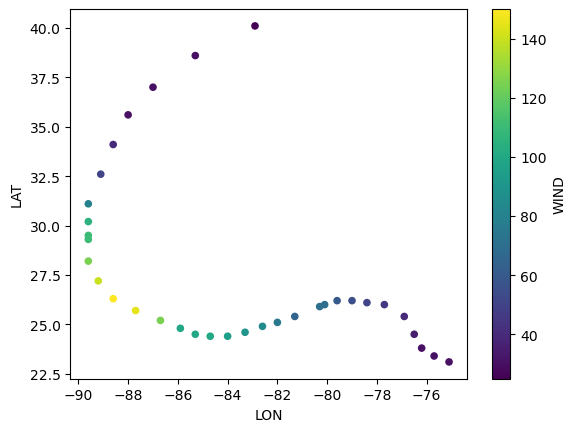

In [192]:
katrina = df[df.SID == '2005236N23285']
katrina.plot.scatter(x='LON', y='LAT', c='WIND', colormap='viridis')

### 10) Make time the index on your dataframe

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 716165 entries, 1842-10-25 03:00:00 to 2024-05-27 18:00:00
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   SID       716165 non-null  object 
 1   SEASON    716165 non-null  int64  
 2   NUMBER    716165 non-null  int64  
 3   BASIN     716165 non-null  object 
 4   SUBBASIN  716165 non-null  object 
 5   NAME      390393 non-null  object 
 6   NATURE    716165 non-null  object 
 7   LAT       716165 non-null  float64
 8   LON       716165 non-null  float64
 9   WIND      157570 non-null  float64
 10  PRES      160275 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 65.6+ MB


In [201]:
df_time = df
df_time

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27 06:00:00,2024147N19089,2024,27,NI,BB,REMAL,NR,23.0325,89.3509,NaN,NaN
2024-05-27 09:00:00,2024147N19089,2024,27,NI,BB,REMAL,NR,23.3337,89.6178,NaN,NaN
2024-05-27 12:00:00,2024147N19089,2024,27,NI,BB,REMAL,NR,23.6263,89.8799,NaN,NaN


### 11) Plot the count of all datapoints per year as a timeseries
Which years stand out as having anomalous hurricane activity?

<Axes: xlabel='ISO_TIME'>

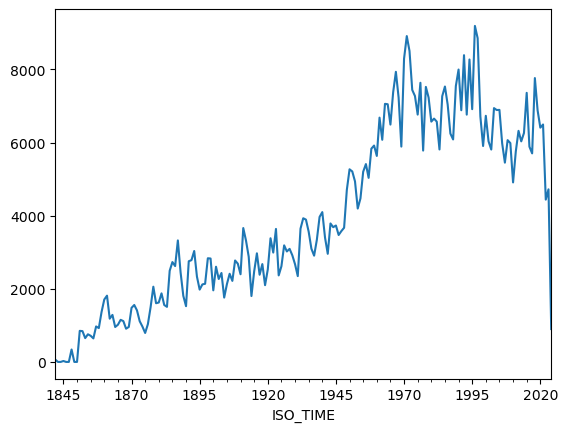

In [203]:
df.resample('YE').count()['SID'].plot()

1970's and 1990's show the highest anomalies for hurricane activity. Noting that there has been a significant increase in hurricaines since the 1840's 